In [3]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

OUT = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"
def load_xi(phase):
    return np.load(f"{OUT}/xirppi_ph{phase:03d}.npy")

# --- the bin edges you used when you COMPUTED xirppi (must match the .npy shape) ---
# e.g. if you binned rp,pi in 1 Mpc/h bins from 0..150:
rp_edges = np.arange(0.0, 140.0 + 1.0, 1.0)   # 141 edges -> 140 bins
pi_edges = np.arange(0.0, 140.0 + 1.0, 1.0)
# sanity check against a file:
assert load_xi(0).shape == (len(rp_edges)-1, len(pi_edges)-1), \
    f"edges {(len(rp_edges)-1, len(pi_edges)-1)} != xi {load_xi(0).shape}"

theta = np.deg2rad(110.0)
a1, a2 = np.cos(theta), np.sin(theta)
u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0
rp = 0.5*(rp_edges[:-1] + rp_edges[1:])
pi = 0.5*(pi_edges[:-1] + pi_edges[1:])
corners = np.array([[u_min,v_min],[u_min,v_max],[u_max,v_min],[u_max,v_max]])
n_angle, n_offset = 121, 161
ds, min_length = 0.25, 20.0
D = np.hypot(u_max-u_min, v_max-v_min)
t_grid = np.arange(-D, D+ds, ds)

def find_best_line(xi):
    interp = RegularGridInterpolator((rp, pi), xi, bounds_error=False, fill_value=np.nan)
    best_loss, best = np.inf, None
    for phi in np.linspace(0, np.pi, n_angle, endpoint=False):
        normal  = np.array([np.cos(phi),  np.sin(phi)])
        tangent = np.array([-np.sin(phi), np.cos(phi)])
        cmin, cmax = (corners @ normal).min(), (corners @ normal).max()
        for c in np.linspace(cmin, cmax, n_offset):
            uv = c*normal + t_grid[:,None]*tangent
            uv = uv[(uv[:,0]>=u_min)&(uv[:,0]<=u_max)&(uv[:,1]>=v_min)&(uv[:,1]<=v_max)]
            if len(uv) < 2 or (len(uv)-1)*ds < min_length:
                continue
            rp_line = a1*uv[:,0] - a2*uv[:,1]
            pi_line = a2*uv[:,0] + a1*uv[:,1]
            vals = interp(np.c_[rp_line, pi_line]); vals = vals[np.isfinite(vals)]
            if len(vals) < 2:
                continue
            loss = np.mean(vals**2)
            if loss < best_loss:
                best_loss, best = loss, (phi, c, rp_line, pi_line)
    return best_loss, best

lines = []
for phase in range(25):
    _, best = find_best_line(load_xi(phase))
    phi, c, rp_line, pi_line = best
    lines.append((rp_line, pi_line))
    print(f"ph{phase:03d}: phi={np.degrees(phi):7.2f} deg, c={c:7.2f}")

ph000: phi= 177.02 deg, c= -35.81
ph001: phi= 178.51 deg, c= -34.60
ph002: phi= 178.51 deg, c= -35.75
ph003: phi= 177.02 deg, c= -35.42
ph004: phi= 172.56 deg, c= -37.22
ph005: phi=  93.72 deg, c= -72.40
ph006: phi=   1.49 deg, c=  31.89
ph007: phi= 178.51 deg, c= -33.84
ph008: phi= 177.02 deg, c= -36.98
ph009: phi= 177.02 deg, c= -35.03
ph010: phi= 177.02 deg, c= -36.59
ph011: phi= 177.02 deg, c= -37.37
ph012: phi=   0.00 deg, c=  33.75
ph013: phi= 178.51 deg, c= -37.67
ph014: phi= 177.02 deg, c= -35.81
ph015: phi= 174.05 deg, c= -37.34
ph016: phi=   2.98 deg, c=  30.75
ph017: phi=   0.00 deg, c=  35.62
ph018: phi=   1.49 deg, c=  33.80
ph019: phi= 175.54 deg, c= -35.40
ph020: phi=   4.46 deg, c=  31.98
ph021: phi=   0.00 deg, c=  35.62
ph022: phi=   1.49 deg, c=  34.57
ph023: phi= 177.02 deg, c= -36.59
ph024: phi=   4.46 deg, c=  30.79



using 24 mocks (skipped [5])
mock means: angle=18.70 deg, perp=-35.01, slope=3.032, rp-intercept=-112.67
data cov:
 [[8.91198926 5.01450461]
 [5.01450461 4.10905236]] 
Hartlap = 0.8695652173913043

cond(J) = 19.1   (high => angle & offset nearly redundant)
sigma(Om) = 0.0423  (13.4%)
sigma(b)  = 0.486    corr(Om,b) = +0.97
sigma(f)  = 0.0322   (f_fid = 0.762)


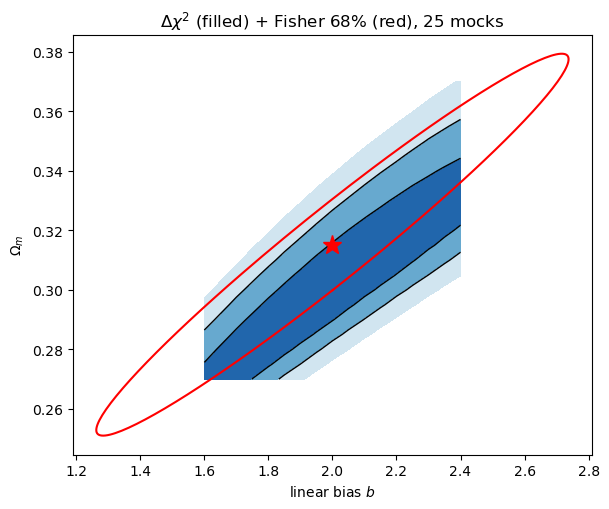

In [6]:
import numpy as np, camb
from mcfit import P2xi
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ============================ CONFIG ============================
# c000-exact fixed cosmology; Om is the only knob (carries shape + f + AP).
H0, ombh2, ns, As, mnu = 67.36, 0.02237, 0.9649, 2.0830e-9, 0.06
Z        = 0.5
OM_FID   = 0.3152      # c000 truth -> alpha = 1, f matches the mocks
B_FID    = 2.00        # set to your AbacusHOD-implied linear bias
KMAX, NPK = 20.0, 800

SPI_MAX, DSPI = 90.0, 0.5          # (sigma,pi) grid the model crossing is read off
S_BAND = (40.0, 80.0)              # same band as your mock fit
MU_WIN = (0.30, 0.97)              # isolates the single Kaiser zero-crossing branch

OM_GRID = np.linspace(0.27, 0.37, 21)
B_GRID  = np.linspace(1.60, 2.40, 17)

# data vector definition (applied identically to mocks and model):
#   'angle_perp' -> (line angle [deg], signed perp distance from origin)
#   'slope_inter'-> (d rp / d pi, rp-intercept at pi=0)   # matches your {slope,offset}
DATA_VECTOR = 'angle_perp'
# ================================================================

_tcache = {}
def template(Om):
    key = round(Om, 6)
    if key in _tcache: return _tcache[key]
    omnuh2 = mnu / 93.14
    omch2  = Om*(H0/100)**2 - ombh2 - omnuh2        # Om = TOTAL matter (incl. nu)
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu, omk=0.0)
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_matter_power(redshifts=[Z], kmax=KMAX)
    pars.NonLinear = camb.model.NonLinear_none
    res = camb.get_results(pars)
    kh, _, pk = res.get_matter_power_spectrum(minkh=1e-4, maxkh=KMAX, npoints=NPK)
    f = (res.get_fsigma8()/res.get_sigma8())[0]
    r, xi = P2xi(kh, l=0)(pk[0], extrap=True)
    c2 = cumulative_trapezoid(xi*r**2, r, initial=0)
    c4 = cumulative_trapezoid(xi*r**4, r, initial=0)
    out = dict(f=f,
               f0 =interp1d(r, xi,         bounds_error=False, fill_value=0.0),
               fb =interp1d(r, 3*c2/r**3,  bounds_error=False, fill_value=0.0),
               fbb=interp1d(r, 5*c4/r**5,  bounds_error=False, fill_value=0.0),
               DM =res.comoving_radial_distance(Z),   # flat -> D_M [Mpc]
               Hz =res.hubble_parameter(Z))           # [km/s/Mpc]
    _tcache[key] = out
    return out

_fid = template(OM_FID)
def alpha(Om):
    t = template(Om)
    return t['DM']/_fid['DM'], _fid['Hz']/t['Hz']      # (alpha_perp, alpha_par)

ax = np.arange(0.0, SPI_MAX + DSPI, DSPI)
SIG, PI = np.meshgrid(ax, ax)                           # SIG[i,j]=ax[j], PI[i,j]=ax[i]

def model_xi(Om, b):
    t = template(Om); beta = t['f']/b
    ap, al = alpha(Om)
    st = np.clip(np.sqrt((ap*SIG)**2 + (al*PI)**2), 1e-3, None)
    mu = (al*PI)/st
    P2 = 0.5*(3*mu**2 - 1); P4 = (35*mu**4 - 30*mu**2 + 3)/8
    C0 = 1 + 2*beta/3 + beta**2/5
    C2 = 4*beta/3 + 4*beta**2/7
    C4 = 8*beta**2/35
    f0, fb, fbb = t['f0'], t['fb'], t['fbb']
    return C0*f0(st) + C2*(f0(st)-fb(st))*P2 + C4*(f0(st)+2.5*fb(st)-3.5*fbb(st))*P4

def crossing_points(XI):
    pts = []
    for j, sig in enumerate(ax):
        col = XI[:, j]; pir = ax
        s  = np.hypot(sig, pir); mu = pir/np.clip(s, 1e-6, None)
        m  = (s>=S_BAND[0]) & (s<=S_BAND[1]) & (mu>=MU_WIN[0]) & (mu<=MU_WIN[1])
        idx = np.where(m)[0]
        if len(idx) < 2: continue
        sgn = np.sign(col[idx])
        for k in np.where(sgn[:-1]*sgn[1:] < 0)[0]:
            i0, i1 = idx[k], idx[k+1]; y0, y1 = col[i0], col[i1]
            t = y0/(y0 - y1)
            pts.append((sig, pir[i0] + t*(pir[i1]-pir[i0])))
    return np.asarray(pts)

def summarize(x, y):                                    # x = rp/sigma, y = pi
    x, y = np.asarray(x, float), np.asarray(y, float)
    x0, y0 = x.mean(), y.mean()
    w, v = np.linalg.eigh(np.cov(np.vstack([x-x0, y-y0])))
    dx, dy = v[:, np.argmax(w)]; L = np.hypot(dx, dy)
    angle = np.degrees(np.arctan2(dy, dx)) % 180.0
    perp  = (-x0*dy + y0*dx)/L                           # signed dist origin->line
    slope = dx/dy if abs(dy) > 1e-12 else np.inf         # d rp / d pi
    return dict(angle=angle, perp=perp, slope=slope, inter=x0 - slope*y0)

def vec(s):
    return np.array([s['angle'], s['perp']]) if DATA_VECTOR=='angle_perp' \
           else np.array([s['slope'], s['inter']])

def predict(Om, b):
    P = crossing_points(model_xi(Om, b))
    return vec(summarize(P[:, 0], P[:, 1]))

# ----------------- data vector from the 25 mocks -----------------
# uses `lines` (list of (rp_line, pi_line)) already produced by your fitter.
SKIP = {5}
USE_BAND = False                      # full fitted segment; set True to re-cut to S_BAND

def restrict_band(rp_l, pi_l):
    rp_l, pi_l = np.asarray(rp_l), np.asarray(pi_l)
    if not USE_BAND:
        return rp_l, pi_l
    s = np.hypot(rp_l, pi_l); m = (s>=S_BAND[0]) & (s<=S_BAND[1])
    return rp_l[m], pi_l[m]

summ = []
for i,(rl,pl) in enumerate(lines):
    if i in SKIP:
        continue
    x, y = restrict_band(rl, pl)
    if len(x) < 3:                    # need >=3 for a meaningful covariance/eigvec
        print(f"  dropping ph{i:03d}: only {len(x)} pts after band cut")
        continue
    summ.append(summarize(x, y))

D = np.array([vec(s) for s in summ])
d_mean, Cov = D.mean(0), np.cov(D, rowvar=False)
Nm, p = len(D), 2
hartlap = (Nm - p - 2)/(Nm - 1)
Psi = hartlap * np.linalg.inv(Cov)
print(f"\nusing {Nm} mocks (skipped {sorted(SKIP)})")
print(f"mock means: angle={np.mean([s['angle'] for s in summ]):.2f} deg, "
      f"perp={np.mean([s['perp'] for s in summ]):.2f}, "
      f"slope={np.mean([s['slope'] for s in summ]):.3f}, "
      f"rp-intercept={np.mean([s['inter'] for s in summ]):.2f}")
print("data cov:\n", Cov, "\nHartlap =", hartlap)
# ----------------------------- scan -----------------------------
CHI2 = np.empty((len(OM_GRID), len(B_GRID)))
for i, Om in enumerate(OM_GRID):
    for jb, b in enumerate(B_GRID):
        d = predict(Om, b) - d_mean
        CHI2[i, jb] = d @ Psi @ d
dchi2 = CHI2 - CHI2.min()

# -------------------- Fisher at the fiducial --------------------
def jac(Om0, b0, dOm=0.004, db=0.04):
    mO = (predict(Om0+dOm, b0) - predict(Om0-dOm, b0))/(2*dOm)
    mb = (predict(Om0, b0+db) - predict(Om0, b0-db))/(2*db)
    return np.column_stack([mO, mb])
J = jac(OM_FID, B_FID)
F = J.T @ Psi @ J
Cpar = np.linalg.inv(F)
sOm, sb = np.sqrt(np.diag(Cpar)); rho = Cpar[0,1]/(sOm*sb)
fp = (template(OM_FID+0.004)['f'] - template(OM_FID-0.004)['f'])/0.008
print(f"\ncond(J) = {np.linalg.cond(J):.1f}   (high => angle & offset nearly redundant)")
print(f"sigma(Om) = {sOm:.4f}  ({100*sOm/OM_FID:.1f}%)")
print(f"sigma(b)  = {sb:.3f}    corr(Om,b) = {rho:+.2f}")
print(f"sigma(f)  = {abs(fp)*sOm:.4f}   (f_fid = {_fid['f']:.3f})")

# ---------------------------- plot ------------------------------
fig, axc = plt.subplots(figsize=(6.2, 5.2))
axc.contourf(B_GRID, OM_GRID, dchi2, levels=[0,2.30,6.18,11.83],
             colors=['#2166ac','#67a9cf','#d1e5f0'])
axc.contour(B_GRID, OM_GRID, dchi2, levels=[2.30,6.18], colors='k', linewidths=1)
# Fisher 68% ellipse at the truth
th = np.linspace(0, 2*np.pi, 200)
w, V = np.linalg.eigh(Cpar); E = (V*np.sqrt(w*2.30)) @ np.array([np.cos(th), np.sin(th)])
axc.plot(B_FID + E[1], OM_FID + E[0], 'r-', lw=1.5)
axc.plot(B_FID, OM_FID, 'r*', ms=14)
axc.set_xlabel('linear bias $b$'); axc.set_ylabel(r'$\Omega_m$')
axc.set_title(r'$\Delta\chi^2$ (filled) + Fisher 68% (red), 25 mocks')
plt.tight_layout(); plt.show()

In [5]:
for i,(rl,pl) in enumerate(lines):
    s = np.hypot(rl, pl)
    print(f"ph{i:03d}: {((s>=40)&(s<=80)).sum():4d} pts in band   (s range {s.min():.1f}–{s.max():.1f})")

ph000:  200 pts in band   (s range 40.3–77.0)
ph001:  196 pts in band   (s range 39.5–77.1)
ph002:  200 pts in band   (s range 40.6–77.6)
ph003:  199 pts in band   (s range 39.9–76.8)
ph004:  202 pts in band   (s range 40.3–75.5)
ph005:    0 pts in band   (s range 80.4–91.1)
ph006:  186 pts in band   (s range 38.1–77.5)
ph007:  191 pts in band   (s range 38.9–76.8)
ph008:  201 pts in band   (s range 41.2–77.5)
ph009:  196 pts in band   (s range 39.6–76.6)
ph010:  201 pts in band   (s range 40.8–77.4)
ph011:  201 pts in band   (s range 41.5–77.7)
ph012:  194 pts in band   (s range 39.3–77.6)
ph013:  200 pts in band   (s range 42.3–78.5)
ph014:  200 pts in band   (s range 40.3–77.0)
ph015:  201 pts in band   (s range 40.8–76.2)
ph016:  185 pts in band   (s range 37.7–77.9)
ph017:  200 pts in band   (s range 40.9–78.4)
ph018:  198 pts in band   (s range 39.8–78.5)
ph019:  196 pts in band   (s range 39.4–76.1)
ph020:  195 pts in band   (s range 39.2–79.3)
ph021:  200 pts in band   (s range

ph000: phi= 177.02 deg, c= -35.81
ph001: phi= 178.51 deg, c= -34.60
ph002: phi= 178.51 deg, c= -35.75
ph003: phi= 177.02 deg, c= -35.42
ph004: phi= 172.56 deg, c= -37.22
ph005: phi=  93.72 deg, c= -72.40
ph006: phi=   1.49 deg, c=  31.89
ph007: phi= 178.51 deg, c= -33.84
ph008: phi= 177.02 deg, c= -36.98
ph009: phi= 177.02 deg, c= -35.03
ph010: phi= 177.02 deg, c= -36.59
ph011: phi= 177.02 deg, c= -37.37
ph012: phi=   0.00 deg, c=  33.75
ph013: phi= 178.51 deg, c= -37.67
ph014: phi= 177.02 deg, c= -35.81
ph015: phi= 174.05 deg, c= -37.34
ph016: phi=   2.98 deg, c=  30.75
ph017: phi=   0.00 deg, c=  35.62
ph018: phi=   1.49 deg, c=  33.80
ph019: phi= 175.54 deg, c= -35.40
ph020: phi=   4.46 deg, c=  31.98
ph021: phi=   0.00 deg, c=  35.62
ph022: phi=   1.49 deg, c=  34.57
ph023: phi= 177.02 deg, c= -36.59
ph024: phi=   4.46 deg, c=  30.79

using 24 mocks (skipped [5])
mock means: angle=18.70 deg, perp=35.01, slope=3.032, rp-intercept=-112.67
data cov:
 [[ 8.91198926 -5.01450461]
 [-5.01

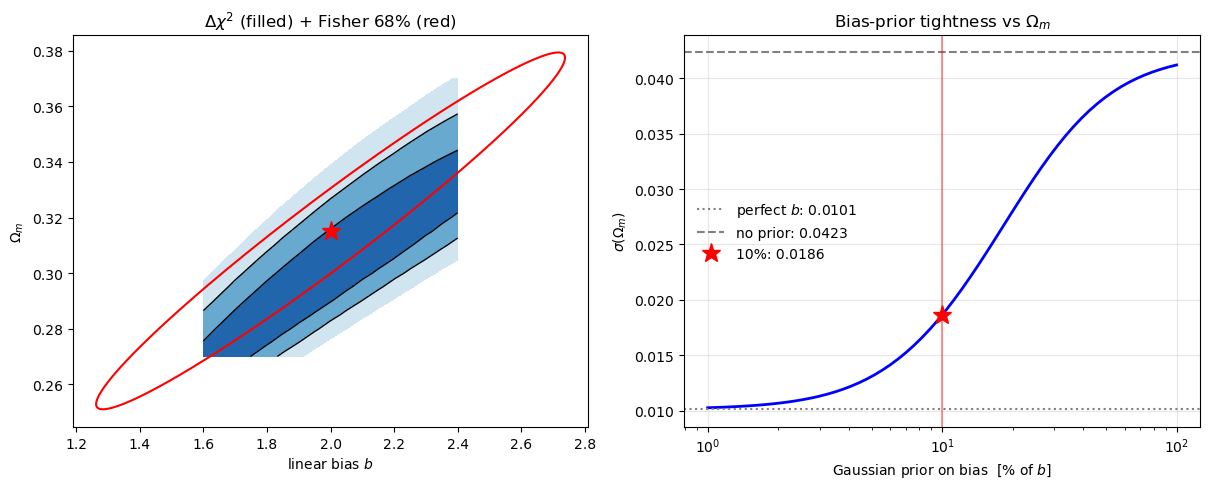

In [10]:
# ============================================================================
#  Zero-crossing {angle, offset}  ->  Fisher forecast on (Om, b)  + bias-prior sweep
#  Self-contained. Requires: numpy, scipy, matplotlib, camb, mcfit
# ============================================================================
import numpy as np, camb
from mcfit import P2xi
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, RegularGridInterpolator
import matplotlib.pyplot as plt

# ----------------------------- CONFIG ---------------------------------------
OUT      = "/pscratch/sd/l/lado/ZeroCrossing/abacus_lrg_mocks"
N_PHASE  = 25
SKIP     = {5}                       # ph005: crossing at s~80-91, off-band outlier
USE_BAND = True                      # re-cut mock lines to S_BAND before summarizing

# bin edges used when xirppi was COMPUTED (must match .npy shape) -- EDIT IF NEEDED
rp_edges = np.arange(0.0, 140.0 + 1.0, 1.0)
pi_edges = np.arange(0.0, 140.0 + 1.0, 1.0)

# fixed cosmology (c000-exact); Om is the only knob (shape + f + AP)
H0, ombh2, ns, As, mnu = 67.36, 0.02237, 0.9649, 2.0830e-9, 0.06
Z        = 0.5
OM_FID   = 0.3152                     # c000 truth -> alpha=1 at the data
B_FID    = 2.00
KMAX, NPK = 20.0, 800

SPI_MAX, DSPI = 90.0, 0.5            # model (sigma,pi) grid
S_BAND = (40.0, 80.0)
MU_WIN = (0.30, 0.97)               # isolate single Kaiser zero-crossing branch
REF    = np.array([0.0, 1.0])       # line orientation anchor (lines run ~ +pi)

OM_GRID = np.linspace(0.27, 0.37, 21)
B_GRID  = np.linspace(1.60, 2.40, 17)
DATA_VECTOR = 'angle_perp'          # or 'slope_inter'

# fitter search box (rotated theta=110deg frame)
theta = np.deg2rad(110.0)
a1, a2 = np.cos(theta), np.sin(theta)
u_min, u_max = 0.0, 60.0
v_min, v_max = -70.0, -20.0
n_angle, n_offset = 121, 161
ds, min_length = 0.25, 20.0
# ----------------------------------------------------------------------------

def load_xi(phase):
    return np.load(f"{OUT}/xirppi_ph{phase:03d}.npy")

assert load_xi(0).shape == (len(rp_edges)-1, len(pi_edges)-1), \
    f"edges {(len(rp_edges)-1, len(pi_edges)-1)} != xi {load_xi(0).shape}"

rp = 0.5*(rp_edges[:-1] + rp_edges[1:])
pi = 0.5*(pi_edges[:-1] + pi_edges[1:])

# ============================== FITTER ======================================
corners = np.array([[u_min,v_min],[u_min,v_max],[u_max,v_min],[u_max,v_max]])
D = np.hypot(u_max-u_min, v_max-v_min)
t_grid = np.arange(-D, D+ds, ds)

def find_best_line(xi):
    interp = RegularGridInterpolator((rp, pi), xi, bounds_error=False, fill_value=np.nan)
    best_loss, best = np.inf, None
    for phi in np.linspace(0, np.pi, n_angle, endpoint=False):
        normal  = np.array([np.cos(phi),  np.sin(phi)])
        tangent = np.array([-np.sin(phi), np.cos(phi)])
        cmin, cmax = (corners @ normal).min(), (corners @ normal).max()
        for c in np.linspace(cmin, cmax, n_offset):
            uv = c*normal + t_grid[:,None]*tangent
            uv = uv[(uv[:,0]>=u_min)&(uv[:,0]<=u_max)&(uv[:,1]>=v_min)&(uv[:,1]<=v_max)]
            if len(uv) < 2 or (len(uv)-1)*ds < min_length:
                continue
            rp_line = a1*uv[:,0] - a2*uv[:,1]
            pi_line = a2*uv[:,0] + a1*uv[:,1]
            vals = interp(np.c_[rp_line, pi_line]); vals = vals[np.isfinite(vals)]
            if len(vals) < 2:
                continue
            loss = np.mean(vals**2)
            if loss < best_loss:
                best_loss, best = loss, (phi, c, rp_line, pi_line)
    return best_loss, best

lines = []
for phase in range(N_PHASE):
    _, best = find_best_line(load_xi(phase))
    phi, c, rp_line, pi_line = best
    lines.append((rp_line, pi_line))
    print(f"ph{phase:03d}: phi={np.degrees(phi):7.2f} deg, c={c:7.2f}")

# ========================= LINE CHARACTERIZATION ============================
def summarize(x, y, ref=REF):
    x, y = np.asarray(x, float), np.asarray(y, float)
    x0, y0 = x.mean(), y.mean()
    w, v = np.linalg.eigh(np.cov(np.vstack([x-x0, y-y0])))
    d = v[:, np.argmax(w)]
    if d @ ref < 0:                  # deterministic orientation (kills sign/seam flips)
        d = -d
    dx, dy = d
    nx, ny = -dy, dx
    angle = np.degrees(np.arctan2(dy, dx))      # no %180; ref fixes the branch
    perp  = x0*nx + y0*ny                        # signed dist origin->line
    slope = dx/dy if abs(dy) > 1e-9 else np.inf  # d rp / d pi
    inter = x0 - slope*y0
    return dict(angle=angle, perp=perp, slope=slope, inter=inter)

def vec(s):
    return np.array([s['angle'], s['perp']]) if DATA_VECTOR=='angle_perp' \
           else np.array([s['slope'], s['inter']])

def restrict_band(rp_l, pi_l):
    rp_l, pi_l = np.asarray(rp_l), np.asarray(pi_l)
    if not USE_BAND:
        return rp_l, pi_l
    s = np.hypot(rp_l, pi_l); m = (s>=S_BAND[0]) & (s<=S_BAND[1])
    return rp_l[m], pi_l[m]

summ = []
for i,(rl,pl) in enumerate(lines):
    if i in SKIP:
        continue
    x, y = restrict_band(rl, pl)
    if len(x) < 3:
        print(f"  dropping ph{i:03d}: only {len(x)} pts after band cut"); continue
    summ.append(summarize(x, y))

D = np.array([vec(s) for s in summ])
d_mean, Cov = D.mean(0), np.cov(D, rowvar=False)
Nm, p = len(D), 2
hartlap = (Nm - p - 2)/(Nm - 1)
Psi = hartlap * np.linalg.inv(Cov)
print(f"\nusing {Nm} mocks (skipped {sorted(SKIP)})")
print(f"mock means: angle={np.mean([s['angle'] for s in summ]):.2f} deg, "
      f"perp={np.mean([s['perp'] for s in summ]):.2f}, "
      f"slope={np.mean([s['slope'] for s in summ]):.3f}, "
      f"rp-intercept={np.mean([s['inter'] for s in summ]):.2f}")
print("data cov:\n", Cov, "\nHartlap =", hartlap)

# ============================ LINEAR-THEORY MODEL ===========================
_tcache = {}
def template(Om):
    key = round(Om, 6)
    if key in _tcache: return _tcache[key]
    omnuh2 = mnu / 93.14
    omch2  = Om*(H0/100)**2 - ombh2 - omnuh2
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu, omk=0.0)
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_matter_power(redshifts=[Z], kmax=KMAX)
    pars.NonLinear = camb.model.NonLinear_none
    res = camb.get_results(pars)
    kh, _, pk = res.get_matter_power_spectrum(minkh=1e-4, maxkh=KMAX, npoints=NPK)
    f = (res.get_fsigma8()/res.get_sigma8())[0]
    r, xi = P2xi(kh, l=0)(pk[0], extrap=True)
    c2 = cumulative_trapezoid(xi*r**2, r, initial=0)
    c4 = cumulative_trapezoid(xi*r**4, r, initial=0)
    out = dict(f=f,
               f0 =interp1d(r, xi,        bounds_error=False, fill_value=0.0),
               fb =interp1d(r, 3*c2/r**3, bounds_error=False, fill_value=0.0),
               fbb=interp1d(r, 5*c4/r**5, bounds_error=False, fill_value=0.0),
               DM =res.comoving_radial_distance(Z),
               Hz =res.hubble_parameter(Z))
    _tcache[key] = out
    return out

_fid = template(OM_FID)
def alpha(Om):
    t = template(Om)
    return t['DM']/_fid['DM'], _fid['Hz']/t['Hz']     # (alpha_perp, alpha_par)

axg = np.arange(0.0, SPI_MAX + DSPI, DSPI)
SIG, PI = np.meshgrid(axg, axg)

def model_xi(Om, b):
    t = template(Om); beta = t['f']/b
    ap, al = alpha(Om)
    st = np.clip(np.sqrt((ap*SIG)**2 + (al*PI)**2), 1e-3, None)
    mu = (al*PI)/st
    P2 = 0.5*(3*mu**2 - 1); P4 = (35*mu**4 - 30*mu**2 + 3)/8
    C0 = 1 + 2*beta/3 + beta**2/5
    C2 = 4*beta/3 + 4*beta**2/7
    C4 = 8*beta**2/35
    f0, fb, fbb = t['f0'], t['fb'], t['fbb']
    return C0*f0(st) + C2*(f0(st)-fb(st))*P2 + C4*(f0(st)+2.5*fb(st)-3.5*fbb(st))*P4

def crossing_points(XI):
    pts = []
    for j, sig in enumerate(axg):
        col = XI[:, j]; pir = axg
        s  = np.hypot(sig, pir); mu = pir/np.clip(s, 1e-6, None)
        m  = (s>=S_BAND[0]) & (s<=S_BAND[1]) & (mu>=MU_WIN[0]) & (mu<=MU_WIN[1])
        idx = np.where(m)[0]
        if len(idx) < 2: continue
        sgn = np.sign(col[idx])
        for k in np.where(sgn[:-1]*sgn[1:] < 0)[0]:
            i0, i1 = idx[k], idx[k+1]; y0, y1 = col[i0], col[i1]
            tt = y0/(y0 - y1)
            pts.append((sig, pir[i0] + tt*(pir[i1]-pir[i0])))
    return np.asarray(pts)

def predict(Om, b):
    P = crossing_points(model_xi(Om, b))
    return vec(summarize(P[:, 0], P[:, 1]))

# ================================ SCAN ======================================
CHI2 = np.empty((len(OM_GRID), len(B_GRID)))
for i, Om in enumerate(OM_GRID):
    for jb, b in enumerate(B_GRID):
        dd = predict(Om, b) - d_mean
        CHI2[i, jb] = dd @ Psi @ dd
dchi2 = CHI2 - CHI2.min()

# ========================= FISHER AT FIDUCIAL ===============================
def jac(Om0, b0, dOm=0.004, db=0.04):
    mO = (predict(Om0+dOm, b0) - predict(Om0-dOm, b0))/(2*dOm)
    mb = (predict(Om0, b0+db) - predict(Om0, b0-db))/(2*db)
    return np.column_stack([mO, mb])
J = jac(OM_FID, B_FID)
F = J.T @ Psi @ J
Cpar = np.linalg.inv(F)
sOm, sb = np.sqrt(np.diag(Cpar)); rho = Cpar[0,1]/(sOm*sb)
fp = (template(OM_FID+0.004)['f'] - template(OM_FID-0.004)['f'])/0.008
print(f"\ncond(J) = {np.linalg.cond(J):.1f}")
print(f"sigma(Om) marg = {sOm:.4f}  ({100*sOm/OM_FID:.1f}%)")
print(f"sigma(b)       = {sb:.3f}    corr(Om,b) = {rho:+.2f}")
print(f"sigma(f)       = {abs(fp)*sOm:.4f}   (f_fid = {_fid['f']:.3f})")

# ===================== BIAS-PRIOR -> sigma(Om) ==============================
def sigma_Om_given_bprior(sigma_b):
    P = np.zeros((2, 2)); P[1, 1] = 1.0/sigma_b**2
    return np.sqrt(np.linalg.inv(F + P)[0, 0])

cond_lim = np.sqrt(1.0/F[0,0])               # perfect b
marg_lim = np.sqrt(np.linalg.inv(F)[0,0])    # no prior
sig_b_10 = 0.10 * B_FID
print(f"\nperfect b (conditional): sigma(Om) = {cond_lim:.4f}")
print(f"no prior  (marginalized): sigma(Om) = {marg_lim:.4f}")
print(f"10% bias prior (sig_b={sig_b_10:.3f}): sigma(Om) = "
      f"{sigma_Om_given_bprior(sig_b_10):.4f}  "
      f"({100*sigma_Om_given_bprior(sig_b_10)/OM_FID:.1f}%)")

# =============================== PLOTS ======================================
fig, (axc, axp) = plt.subplots(1, 2, figsize=(12.2, 5.0))

# (1) Om-b constraint
axc.contourf(B_GRID, OM_GRID, dchi2, levels=[0,2.30,6.18,11.83],
             colors=['#2166ac','#67a9cf','#d1e5f0'])
axc.contour(B_GRID, OM_GRID, dchi2, levels=[2.30,6.18], colors='k', linewidths=1)
th = np.linspace(0, 2*np.pi, 200)
w, V = np.linalg.eigh(Cpar); E = (V*np.sqrt(w*2.30)) @ np.array([np.cos(th), np.sin(th)])
axc.plot(B_FID + E[1], OM_FID + E[0], 'r-', lw=1.5)
axc.plot(B_FID, OM_FID, 'r*', ms=14)
axc.set_xlabel('linear bias $b$'); axc.set_ylabel(r'$\Omega_m$')
axc.set_title(r'$\Delta\chi^2$ (filled) + Fisher 68% (red)')

# (2) bias-prior sweep
fracs = np.logspace(-2, 0, 60)
sig_Om = np.array([sigma_Om_given_bprior(fr*B_FID) for fr in fracs])
axp.plot(fracs*100, sig_Om, 'b-', lw=2)
axp.axhline(cond_lim, ls=':',  c='gray', label=f'perfect $b$: {cond_lim:.4f}')
axp.axhline(marg_lim, ls='--', c='gray', label=f'no prior: {marg_lim:.4f}')
axp.axvline(10, ls='-', c='r', alpha=0.4)
axp.plot(10, sigma_Om_given_bprior(sig_b_10), 'r*', ms=14,
         label=f'10%: {sigma_Om_given_bprior(sig_b_10):.4f}')
axp.set_xscale('log'); axp.set_xlabel('Gaussian prior on bias  [% of $b$]')
axp.set_ylabel(r'$\sigma(\Omega_m)$')
axp.set_title('Bias-prior tightness vs $\\Omega_m$')
axp.legend(frameon=False); axp.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
0.0101/0.31

0.03258064516129032